In [1]:
pip install xgboost seaborn pygam mlxtend vegafusion

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 90.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 46.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 91.5 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from pygam import s, f, LinearGAM
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LassoCV
from sklearn import linear_model
from pygam import LinearGAM, s, l
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from numpy.linalg import norm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import altair as alt
import vegafusion



Leitura do dataset e visualização das linhas iniciais.

In [3]:
df_flight = pd.read_csv('data/flight.csv')
df_flight

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


A primeira coluna não é útil

In [4]:
df_flight = df_flight.drop('Unnamed: 0',axis=1)
df_flight

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


AQui utilizamos o método describe para ver as estatisticas das variaveis numericas do dataset

In [ ]:
# Informações
df_flight.info()

# Verificar valores nulos
df_flight.isnull().sum()


### Colunas

As colunas existentes no dataset escolhido são:

1. **airline** – Companhia aérea responsável pelo voo.

2. **flight** – Código ou número identificador do voo.

3. **source_city** – Cidade de origem de onde o voo parte.

4. **departure_time** – Faixa de horário da decolagem (por exemplo: manhã, tarde, noite).

5. **stops** – Número de paradas intermediárias (ex: zero, one, two_or_more).

6. **arrival_time** – Faixa de horário de chegada ao destino.

7. **destination_city** – Cidade de destino para onde o voo está indo.

8. **class** – Classe da passagem (por exemplo: Economy, Business).

9. **duration** – Duração total do voo em horas.

10. **days_left** – Quantidade de dias restantes até a data do voo no momento da coleta dos dados.

11. **price** – Preço da passagem aérea.



### Resumo Estatístico

#### Análise unidimensional



In [ ]:
df_flight.describe()

In [6]:
# Pela quantidade de observações, é necessário desabilitar o máximo de colunas padrão do Altair (5000)

alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

##### Histogramas

In [ ]:
num_cols = ["duration", "days_left", "price"]

charts = [
    alt.Chart(df_flight).mark_bar().encode(
        alt.X(col, type="quantitative", bin=alt.BinParams(maxbins=15), title=col),
        alt.Y("count()", type="quantitative", title="Contagem de ocorrências")
    ).properties(width=150, height=150)
    for col in num_cols
]

histogramas_num = alt.hconcat(*charts).properties(
    title="Distribuição de variáveis numéricas"
)

histogramas_num


In [ ]:
cat_cols = [
    "airline", "source_city", "departure_time", "stops",
    "arrival_time", "destination_city", "class"
]
charts_cat = [
    alt.Chart(df_flight).mark_bar().encode(
        x=alt.X(col, type="nominal", title=col, sort='-y'),
        y=alt.Y("count()", type="quantitative", title="Contagem de ocorrências"),
        tooltip=[col, "count()"]
    ).properties(width=150, height=150)
    for col in cat_cols
]

# organiza os gráficos em uma grade
histogramas_cat = alt.hconcat(*charts_cat[:4]).resolve_scale(y='independent')
if len(cat_cols) > 4:
    row2 = alt.hconcat(*charts_cat[4:]).resolve_scale(y='independent')
    histogramas_cat = alt.vconcat(histogramas_cat, row2)

histogramas_cat = histogramas_cat.properties(
    title="Distribuição de variáveis categóricas"
)

histogramas_cat


##### Boxplots

In [ ]:
col_titles = {
    "duration": "Duração do voo (horas)",
    "days_left": "Dias restantes até o voo",
    "price": "Preço da passagem (R$)"
}


plt.figure(figsize=(15, 4))

# cria um boxplot horizontal para cada variável numérica
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1) 
    sns.boxplot(x=df_flight[col])  
    plt.title(f"Boxplot de {col_titles[col]}")
    plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [10]:
categorical_features = ['airline', 'source_city', 'departure_time', 'stops',
                        'arrival_time', 'destination_city', 'class']
numerical_features = ['duration', 'days_left']


Após isso, aplicaremos transformações às colunas com objetivo de normalizar os dados, isso é necessário pois o k-means calcula distancias e ter alguma variavel numericamente muito maior que as outras ou muito menor pode causar problemas.

In [11]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)
X_prepared = preprocessor.fit_transform(df_flight)

Agora calcularemos a inercia para o k-means utilizando k de 1 até 11, isso serve para escolhermos qual seria o melhor k para usar, a inercia aqui significa a soma das distâncias quadráticas das amostras ao centro do cluster mais próximo.

In [12]:
inertia = []
K_range = range(1, 11) # Testaremos K de 1 a 10

In [13]:
for k in K_range:
    # n_init='auto' é o padrão moderno para evitar warnings futuros
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_model.fit(X_prepared)
    inertia.append(kmeans_model.inertia_)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para K Ótimo')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Uma possibilidade para escolher o k ideal é analisar o "cotovelo" do gráfico, isso é, onde a inercia ainda decresce bastante e após esse valor para de diminuir tanto, nesse caso podemos observar que é o k = 4.

In [14]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_prepared)

In [15]:
df_flight['cluster'] = clusters


print(f"\n### Análise dos {optimal_k} Clusters Encontrados (Médias das Variáveis Numéricas) ###\n")
cluster_analysis_numeric = df_flight.groupby('cluster')[numerical_features].mean().round(2)
print(cluster_analysis_numeric)

for feature in categorical_features:
    print(f"\n--- Distribuição de '{feature}' por Cluster ---")
    print(pd.crosstab(df_flight['cluster'], df_flight[feature]))


### Análise dos 4 Clusters Encontrados (Médias das Variáveis Numéricas) ###

         duration  days_left
cluster                     
0           20.49      13.48
1            7.13      37.63
2            8.02      14.66
3           18.30      37.42

--- Distribuição de 'airline' por Cluster ---
airline  AirAsia  Air_India  GO_FIRST  Indigo  SpiceJet  Vistara
cluster                                                         
0            435      24314       740       0      1820    26692
1           7977      13210     11431   22870      2221    29190
2           6717      17142      9783   20250      3168    37497
3            969      26226      1219       0      1802    34480

--- Distribuição de 'source_city' por Cluster ---
source_city  Bangalore  Chennai  Delhi  Hyderabad  Kolkata  Mumbai
cluster                                                           
0                 9150     7055  10111       7138     9514   11033
1                15102    10789  19067      11876    12688 

**Preparação dos Dados para Regressão Linear**

Preparamos os dados para que possam ser utilizados adequadamente pelo modelo de regressão. O conjuto de dados original contém variáveis categóricas (*cidade de origem, companhia aérea etc*), utilizamos o método:  

```
pd.get_dummies()
```

Cada categoria é transformado numa nova coluna binária (ou preditor binário), permitindo que o modelo interprete a informação qualitativa. Para evitar o problema de multicolinearidade utilizamos o parâmetro:

```
drop_first = True
```

Em seguida, definimos as variáveis:



*   **x:** conjnto de atributos preditores. Removemos as colunas não utilizadas no treinamento: flight, price e cluster;
*   **y:** variável alvo: preço das passagens aéreas.

Os dados são dividos em conjuntos de **treinamento e teste** na proporção de 80% para treino e 20% para teste. 

In [16]:
df_encoded = pd.get_dummies(df_flight, columns=['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'cluster'], drop_first=True)

X = df_encoded.drop(['flight', 'price'], axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Padronização das Variáveis**

Padronização das variáveis numéricas utilizando:

```
StandardScaler()
```

Esse procedimento garante que todas as variáveis estejam na mesma escala, para não haver o problema de atributos com valores maiores dominem o processo de aprendizagem. 

```
fit_transform()
transform()
```
Métodos aplicados somente sobre o conjunto de treinamento e teste, respectivamente. 

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

# REGRESSÃO LINEAR

**Modelo de Regressão Linear**

A regressão linear é um algoritmo de **aprendizagem supervisionada** usado quando a variável alvo é um número real contínuo (no caso, o *preço da passagem aérea*). Ela estabelece a relação entre a variável dependente **y** e uma ou mais variáveis **x** usando a linha de melhor ajuste. Utilizamos o método:

```
fit()
```
Para realizar a estimação dos parâmetros através do **método dos mínimos quadrados ordinários (OLS - *Ordinary Least Squares*)**.  

O modelo assume uma relação linear da forma:

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p
$$

onde:


*   $\hat{y}$ representa o valor estimado do preço; 
*   $\theta_{0}$ é o intercepto;
*   $\theta_{i}$ são os coeficientes de regressão associados a cada variável $x_{i}$.

In [18]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

**Avaliação do Modelo de Regressão Linear**

Avaliamos o desempenho tanto no conjunto de treino (verificar o quanto o modelo aprendeu os padrões dos dados) e teste (medir capacidade de generalização).

Foram utilizadas as seguinte métricas:

*   **$R^2$ (Coeficiente de Determinação):** Mede proporção da variabilidade do preço das passagens explicada pelo modelo. Valor entre 0 e 1, quando mais próximo de 1 melhor o ajuste:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y_i})^2}{\sum (y_i - \bar{y})^2}
$$

*   **MAE (Mean Absolute Error):** Erro médio absoluto entre os valores previstos e os reais, em unidades monetárias:

$$
MAE = \frac{1}{n} \sum |y_i - \hat{y_i}|
$$

*   **RMSE (Root Mean Squared Error):** Erro quadrático médio, penaliza mais grandes discrepâncias:

$$
RMSE = \sqrt{\frac{1}{n} \sum (y_i - \hat{y_i})^2}
$$

Essa métricas permitem avaliar tanto o **ajuste do modelo** (via $R^2$) quanto a **magnitude dos erros de previsão** (via $MAE$ e $RMSE$). 

In [19]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

r2_train = metrics.r2_score(y_train, y_pred_train)
r2_test = metrics.r2_score(y_test, y_pred_test)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))

print("RESULTADOS OLS (Treino vs Teste)")
print(f"R² Treino: {r2_train:.4f}")
print(f"R² Teste:  {r2_test:.4f}")
print(f"MAE Treino: {mae_train:,.2f}")
print(f"MAE Teste:  {mae_test:,.2f}")
print(f"RMSE Treino: {rmse_train:,.2f}")
print(f"RMSE Teste:  {rmse_test:,.2f}")

RESULTADOS OLS (Treino vs Teste)
R² Treino: 0.9123
R² Teste:  0.9122
MAE Treino: 4,559.45
MAE Teste:  4,535.83
RMSE Treino: 6,722.08
RMSE Teste:  6,728.36


Os valores de $R^2$ para treino (0.9115) e (0.9113) são muito próximos, mostrando que o modelo não sofreu overfitting e consegue explicar cerca de 91% da variação no preço das passagens. 

Os erros médios ($MAE ≈ 4.500$ e $RMSE ≈ 6.700$) são consistentes entre treino e teste: sugere modelo estável e robusto nas previsões. 

In [20]:
print("Coeficientes do Modelo")
coeficientes = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
print(coeficientes)

Coeficientes do Modelo
                               Coeficiente
duration                       -418.778454
days_left                     -2433.952141
airline_Air_India              -103.599047
airline_GO_FIRST                438.369693
airline_Indigo                  671.935259
airline_SpiceJet                352.626667
airline_Vistara                1872.165213
source_city_Chennai             -14.220649
source_city_Delhi              -548.485788
source_city_Hyderabad          -568.372254
source_city_Kolkata             590.669884
source_city_Mumbai              -79.652370
departure_time_Early_Morning    369.056279
departure_time_Evening          178.509869
departure_time_Late_Night       101.486786
departure_time_Morning          462.696505
departure_time_Night            124.413121
stops_two_or_more               462.119713
stops_zero                    -2552.915328
arrival_time_Early_Morning     -147.490950
arrival_time_Evening            543.865049
arrival_time_Late_Night        

**a) O preço varia de acordo com a companhia aérea?**

O preço varia sim entre as companhias aéreas. Companhias como Vistara e a Indigo apresentam tarifas médias mais altas, enquanto Air India e Spicejet têm impacto menor. 

**b) Como o preço é afetado quando as passagens são compradas com apenas 1 ou 2 dias de antecedência?**

O coeficiente de **days_left** (-1769.9) mostra que quanto menor o número de dias até a viagem, maior o preço da passagem. Comprar com antecedência reduz o custo, mas adquirir o bilhete próximo a data do voo encarece o valor. 

**c) O preço da passagem muda de acordo com o horário de partida e chegada?**

Tanto o horário de partida (**departure_time**) quanto o de chegada (**arrival_time**) afetam o preço. Voos que partem pela manhã ou a noite apresentam coeficientes positivos sugerem que horários mais convenientes ou de demanda alta tendem a ter preços mais altos. 

**d) Como o preço muda com a alteração da origem e do destino?**

Os coeficientes de **source_city** e **destination_city** indicam diferenças regionais nos preços médios. Voos que envolvem Kolkata têm coeficientes positivos, sugerindo valores mais altos enquanto Delhi e Hyderabad valores mais baixos. 

**e) Como o preço da passagem varia entre a Classe Econômica e a Classe Executiva?**

O coeficiente da variável **class_Economy** (-20804.96) mostra que as passagens da classe enconômica são ₹20.800 mais baratas do que as da classe executiva. A classe de serviço é o principal determinante do valor da passagem aérea. 

**Validação Cruzada (K-Fold)**

Para validar a consistência do modelo, aplicou-se uma validação cruzada com 10 partições (K=10). 

Em cada uma das 10 iterações, o modelo é treinado em 90% dos dados e testado nos 10% restantes, de forma aleatória e balanceada.

In [21]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

resultados = cross_validate(
    pipeline,
    X,
    y,
    cv=kf,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    return_estimator=False
)

print("\n--- Resultados da Avaliação com K-Fold ---")
print("R² médio:", resultados['test_r2'].mean().round(4))
print("MAE médio:", (-resultados['test_neg_mean_absolute_error'].mean()).round(4))
print("RMSE médio:", (-resultados['test_neg_root_mean_squared_error'].mean()).round(4))



--- Resultados da Avaliação com K-Fold ---
R² médio: 0.9122
MAE médio: 4553.17
RMSE médio: 6723.8087


Esses valores confirmam que o modelo apresenta capacidade explicativa e boa generalização, já que o desempenho médio é muito semelhante ao observado na avaliação simples de treino e teste. Isso indica estabilidade e consistência na previsão dos preços das passagens aéreas.

# RIDGE

O modelo **Ridge** adiciona uma penalização L2 na Regressão Lienar, reduzindo o tamanho dos coeficientes para evitar *overfitting*. Função custo para ser minimizada:

$$
\sum_{i=1}^{n} (y_i - \hat{y_i})^2 + \alpha \sum_{j=1}^{p} \theta_j^{2}
$$

O parâmetro $\alpha $ controla a intensidade da penalização.


**Usando K-Folds**

Foram testados diversos valores do parâmetro de regularização $\alpha$ para o modelo Ridge. O objetivo era verificar se o acréscimo da penalização L2 melhoraria o desempenho do modelo em relação à Regressão Linear simples.

In [22]:
alphas = [0.1, 1, 10, 100, 1000, 10000, 100000, 10000000]
resultados_alpha = []

for a in alphas:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', linear_model.Ridge(alpha=a, random_state=42))
    ])

    resultados = cross_validate(
        pipeline, 
        X, 
        y, 
        cv=10,
        scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
    )

    resultados_alpha.append({
        'alpha': a,
        'R2_médio': resultados['test_r2'].mean(),
        'MAE_médio': -resultados['test_neg_mean_absolute_error'].mean(),
        'RMSE_médio': -resultados['test_neg_root_mean_squared_error'].mean()
    })

results = pd.DataFrame(resultados_alpha)
print(results)

        alpha   R2_médio     MAE_médio    RMSE_médio
0         0.1  -0.069468   5013.962484   6485.188248
1         1.0  -0.069464   5013.968055   6485.185096
2        10.0  -0.069423   5014.023891   6485.153737
3       100.0  -0.069024   5014.596248   6484.855367
4      1000.0  -0.065836   5021.743455   6483.372410
5     10000.0  -0.102245   5212.611006   6599.670072
6    100000.0  -2.566983   9246.564756  10710.567503
7  10000000.0 -13.383587  21398.386133  22385.889336


Os resultados mostram que nenhum valor de $\alpha$ produziu desempenho superior.

In [23]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 10000000, 100000000]
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print("Melhor alpha (Ridge):", ridge_cv.alpha_)

Melhor alpha (Ridge): 1.0


Seleção automática do hiperparâmetro $\alpha$ no modelo Ridge via validação cruzada.

In [24]:
model_ridge = linear_model.Ridge(alpha=100)
model_ridge.fit(X_train_scaled, y_train)

Ridge(alpha=100)

In [25]:
y_pred_ridge_train = model_ridge.predict(X_train_scaled)
y_pred_ridge_test = model_ridge.predict(X_test_scaled)

r2_ridge_train = metrics.r2_score(y_train, y_pred_ridge_train)
r2_ridge_test = metrics.r2_score(y_test, y_pred_ridge_test)

mae_ridge_train = metrics.mean_absolute_error(y_train, y_pred_ridge_train)
mae_ridge_test = metrics.mean_absolute_error(y_test, y_pred_ridge_test)

rmse_ridge_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_ridge_train))
rmse_ridge_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge_test))

print("RESULTADOS RIDGE (Treino vs Teste)")
print(f"R² Treino: {r2_ridge_train:.4f}")
print(f"R² Teste:  {r2_ridge_test:.4f}")
print(f"MAE Treino: {mae_ridge_train:,.2f}")
print(f"MAE Teste:  {mae_ridge_test:,.2f}")
print(f"RMSE Treino: {rmse_ridge_train:,.2f}")
print(f"RMSE Teste:  {rmse_ridge_test:,.2f}")

RESULTADOS RIDGE (Treino vs Teste)
R² Treino: 0.9123
R² Teste:  0.9122
MAE Treino: 4,559.60
MAE Teste:  4,535.93
RMSE Treino: 6,722.09
RMSE Teste:  6,728.33


In [26]:
print("Coeficientes do Modelo")
coef_ridge = pd.DataFrame(model_ridge.coef_, X.columns, columns=['Coeficiente'])
print(coef_ridge)

Coeficientes do Modelo
                               Coeficiente
duration                       -418.292012
days_left                     -2430.064321
airline_Air_India              -104.870223
airline_GO_FIRST                435.193781
airline_Indigo                  667.613657
airline_SpiceJet                350.342110
airline_Vistara                1871.210107
source_city_Chennai             -13.947343
source_city_Delhi              -548.158795
source_city_Hyderabad          -568.048043
source_city_Kolkata             590.598057
source_city_Mumbai              -79.312074
departure_time_Early_Morning    368.138769
departure_time_Evening          177.670160
departure_time_Late_Night       101.324423
departure_time_Morning          461.963388
departure_time_Night            123.650247
stops_two_or_more               460.479384
stops_zero                    -2551.276118
arrival_time_Early_Morning     -148.065018
arrival_time_Evening            543.144375
arrival_time_Late_Night        

Mesmo com valor alto de $\alpha$ não há grandes mudanças ($\alpha = 100$). Isso significa que o problema não apresenta multicolinearidade forte nem sobreajuste relevante. O modelo $OLS$ já era suficientemente estável e generalizava bem aos dados. 

# LASSO

O modelo **Lasso** utiliza uma penalização L1, que além de reduzir *overfitting*, também zera alguns coeficientes, funcionando como um método de seleção automática de variáveis:

$$
\sum_{i=1}^{n} (y_i - \hat{y_i})^2 + \alpha \sum_{j=1}^{p} |\theta_j|
$$

O Lasso tende a produzir modelos mais simples e interpretáveis, mantendo apenas as variáveis mais relevantes.  

**Usando K-Folds**

Foram testados diversos valores do parâmetro de regularização $\alpha$ para o modelo Lasso. O objetivo era verificar se o acréscimo da penalização L1 melhoraria o desempenho do modelo em relação à Regressão Linear simples.

In [27]:
# CORRIGIR R^2 NEGATIVO

alphas = [0.1, 1, 10, 100, 500, 800, 1000, 1500]
resultados_alpha = []

for a in alphas:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', linear_model.Lasso(alpha=a, random_state=42))
    ])

    resultados = cross_validate(
        pipeline,
        X,
        y,
        cv=10,
        scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
    )

    resultados_alpha.append({
        'alpha': a,
        'R2_médio': resultados['test_r2'].mean(),
        'MAE_médio': -resultados['test_neg_mean_absolute_error'].mean(),
        'RMSE_médio': -resultados['test_neg_root_mean_squared_error'].mean()
    })

results = pd.DataFrame(resultados_alpha)
print(results)

    alpha  R2_médio    MAE_médio   RMSE_médio
0     0.1 -0.069292  5013.740360  6484.937212
1     1.0 -0.067713  5011.759350  6482.689855
2    10.0 -0.052530  4992.631553  6460.976897
3   100.0  0.037707  4889.676711  6344.246208
4   500.0  0.170698  4813.037493  6208.439454
5   800.0  0.184482  4853.373657  6237.783977
6  1000.0  0.179707  4886.728250  6285.524220
7  1500.0  0.108918  5120.618800  6537.935699


In [28]:
model_lasso = linear_model.Lasso(alpha=800)
model_lasso.fit(X_train_scaled, y_train)

Lasso(alpha=800)

In [29]:
y_pred_lasso_train = model_lasso.predict(X_train_scaled)
y_pred_lasso_test = model_lasso.predict(X_test_scaled)

r2_lasso_train = metrics.r2_score(y_train, y_pred_lasso_train)
r2_lasso_test = metrics.r2_score(y_test, y_pred_lasso_test)

mae_lasso_train = metrics.mean_absolute_error(y_train, y_pred_lasso_train)
mae_lasso_test = metrics.mean_absolute_error(y_test, y_pred_lasso_test)

rmse_lasso_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_lasso_train))
rmse_lasso_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso_test))

print("RESULTADOS LASSO (Treino vs Teste)")
print(f"R² Treino: {r2_lasso_train:.4f}")
print(f"R² Teste:  {r2_lasso_test:.4f}")
print(f"MAE Treino: {mae_lasso_train:,.2f}")
print(f"MAE Teste:  {mae_lasso_test:,.2f}")
print(f"RMSE Treino: {rmse_lasso_train:,.2f}")
print(f"RMSE Teste:  {rmse_lasso_test:,.2f}")

RESULTADOS LASSO (Treino vs Teste)
R² Treino: 0.9020
R² Teste:  0.9019
MAE Treino: 4,620.78
MAE Teste:  4,600.58
RMSE Treino: 7,104.31
RMSE Teste:  7,110.03


In [30]:
print("Coeficientes do Modelo")
coef_lasso = pd.DataFrame(model_lasso.coef_, X.columns, columns=['Coeficiente'])
print(coef_lasso)

Coeficientes do Modelo
                               Coeficiente
duration                          0.000000
days_left                     -1016.037932
airline_Air_India                -0.000000
airline_GO_FIRST                 -0.000000
airline_Indigo                   -0.000000
airline_SpiceJet                  0.000000
airline_Vistara                1132.988774
source_city_Chennai               0.000000
source_city_Delhi                -0.000000
source_city_Hyderabad            -0.000000
source_city_Kolkata               0.000000
source_city_Mumbai                0.000000
departure_time_Early_Morning      0.000000
departure_time_Evening            0.000000
departure_time_Late_Night        -0.000000
departure_time_Morning            0.000000
departure_time_Night             -0.000000
stops_two_or_more                 0.000000
stops_zero                    -1969.728976
arrival_time_Early_Morning       -0.000000
arrival_time_Evening              0.000000
arrival_time_Late_Night        

In [31]:
print("Coeficientes do Modelo (≠ 0)")
coef_lasso = pd.DataFrame(model_lasso.coef_, index=X.columns, columns=['Coeficiente'])
coef_nao_zero = coef_lasso[coef_lasso['Coeficiente'] != 0]
print(coef_nao_zero)

Coeficientes do Modelo (≠ 0)
                  Coeficiente
days_left        -1016.037932
airline_Vistara   1132.988774
stops_zero       -1969.728976
class_Economy   -19995.947955


O Lasso eliminou todas as variáveis menos relevantes, mantendo as que têm maior poder explicativo sobre o preço da passagem. Os resultados nos mostram que:



```
days_left        -1016.037932
airline_Vistara   1132.988774
stops_zero       -1969.728976
class_Economy   -19995.947955
```



O fator mais determinante é o preço. Passagens em classe econômica são muito mais baratas. 

Ter paradas reduz bastante o preço. A diferença principal está entre ter ou não paradas. O número de paradas adicionais tem impacto menor comparado a essa distinção. 


# Comparação Entre os Modelos Lineares

A seguir vamos comparar os resultados entre os modelos: OLS, Ridge e Lasso. 

In [32]:
comparacao_resultados = pd.DataFrame({
    'Modelo': ['OLS', 'Ridge', 'Lasso'],
    'R²': [r2_test, r2_ridge_test, r2_lasso_test],
    'MAE': [mae_test, mae_ridge_test, mae_lasso_test],
    'RMSE': [rmse_test, rmse_ridge_test, rmse_lasso_test]
})

print("Comparação de Desempenho dos Modelos")
print(comparacao_resultados)

Comparação de Desempenho dos Modelos
  Modelo        R²          MAE         RMSE
0    OLS  0.912178  4535.833314  6728.363871
1  Ridge  0.912178  4535.929367  6728.332178
2  Lasso  0.901932  4600.584215  7110.028287


In [33]:
coef_ols = pd.Series(model.coef_, index=X.columns)
coef_ridge = pd.Series(model_ridge.coef_, index=X.columns)
coef_lasso = pd.Series(model_lasso.coef_, index=X.columns)

comparacao_coef = pd.DataFrame({
    'OLS': coef_ols,
    'Ridge': coef_ridge,
    'Lasso': coef_lasso
})

print("Comparação dos Coeficientes dos Modelos")
print(comparacao_coef)

normas = pd.DataFrame({
    'Modelo': ['OLS', 'Ridge', 'Lasso'],
    'Norma L1 (∑|coef|)': [norm(coef_ols, 1), norm(coef_ridge, 1), norm(coef_lasso, 1)],
    'Norma L2 (||coef||²)': [norm(coef_ols, 2), norm(coef_ridge, 2), norm(coef_lasso, 2)]
})

print()

print("Comparação das Normas dos Coeficientes")
print(normas)

Comparação dos Coeficientes dos Modelos
                                       OLS         Ridge         Lasso
duration                       -418.778454   -418.292012      0.000000
days_left                     -2433.952141  -2430.064321  -1016.037932
airline_Air_India              -103.599047   -104.870223     -0.000000
airline_GO_FIRST                438.369693    435.193781     -0.000000
airline_Indigo                  671.935259    667.613657     -0.000000
airline_SpiceJet                352.626667    350.342110      0.000000
airline_Vistara                1872.165213   1871.210107   1132.988774
source_city_Chennai             -14.220649    -13.947343      0.000000
source_city_Delhi              -548.485788   -548.158795     -0.000000
source_city_Hyderabad          -568.372254   -568.048043     -0.000000
source_city_Kolkata             590.669884    590.598057      0.000000
source_city_Mumbai              -79.652370    -79.312074      0.000000
departure_time_Early_Morning    369.0

In [34]:
print("Coeficientes do Lasso Diferentes de Zero (Variáveis Selecionadas)")
coef_lasso_df = pd.DataFrame(model_lasso.coef_, index=X.columns, columns=['Coeficiente'])
coef_lasso_ativo = coef_lasso_df[coef_lasso_df['Coeficiente'] != 0]
print(coef_lasso_ativo)


Coeficientes do Lasso Diferentes de Zero (Variáveis Selecionadas)
                  Coeficiente
days_left        -1016.037932
airline_Vistara   1132.988774
stops_zero       -1969.728976
class_Economy   -19995.947955


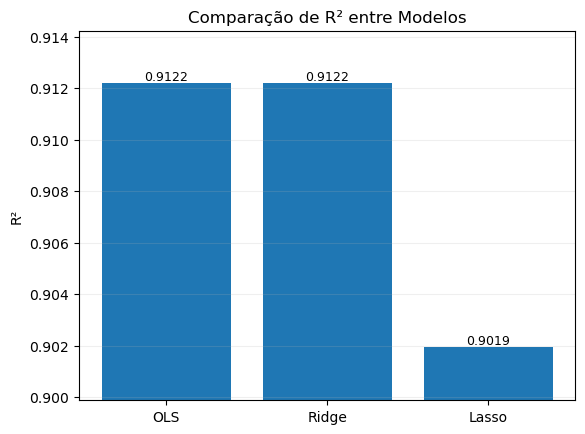

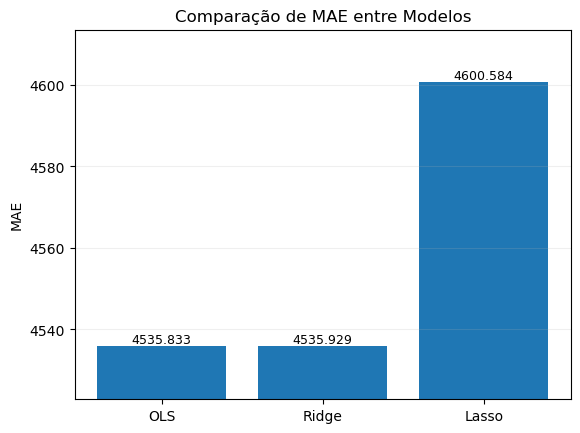

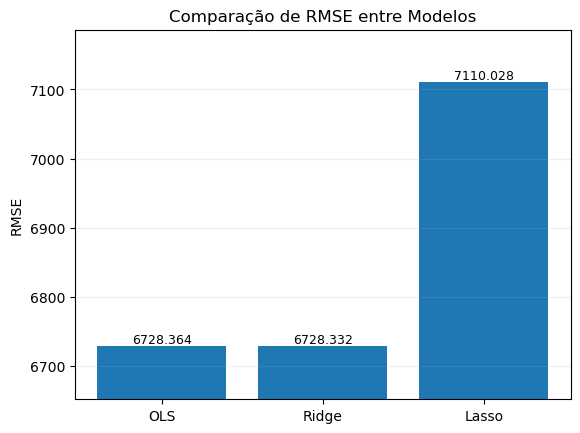

,feature,OLS,Ridge,Lasso
0,duration,-418.778454,-418.292012,0.000000
1,days_left,-2433.952141,-2430.064321,-1016.037932
2,airline_Air_India,-103.599047,-104.870223,-0.000000
3,airline_GO_FIRST,438.369693,435.193781,-0.000000
4,airline_Indigo,671.935259,667.613657,-0.000000
5,airline_SpiceJet,352.626667,350.342110,0.000000
6,airline_Vistara,1872.165213,1871.210107,1132.988774
7,source_city_Chennai,-14.220649,-13.947343,0.000000
8,source_city_Delhi,-548.485788,-548.158795,-0.000000
9,source_city_Hyderabad,-568.372254,-568.048043,-0.000000


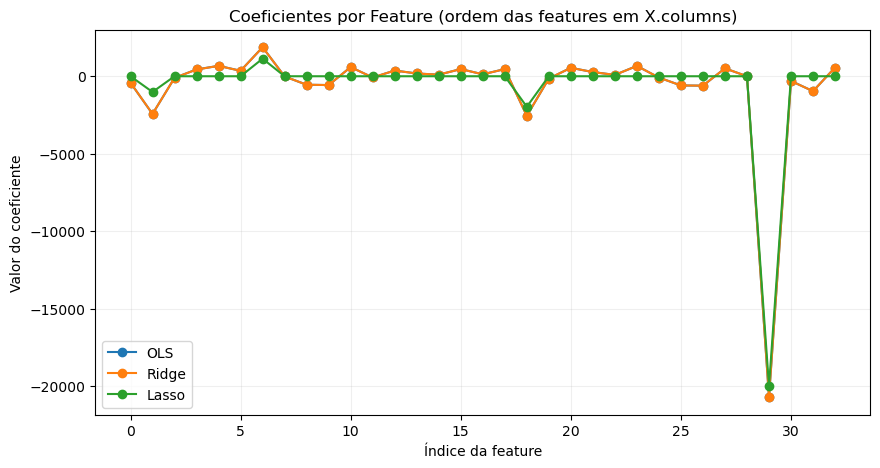

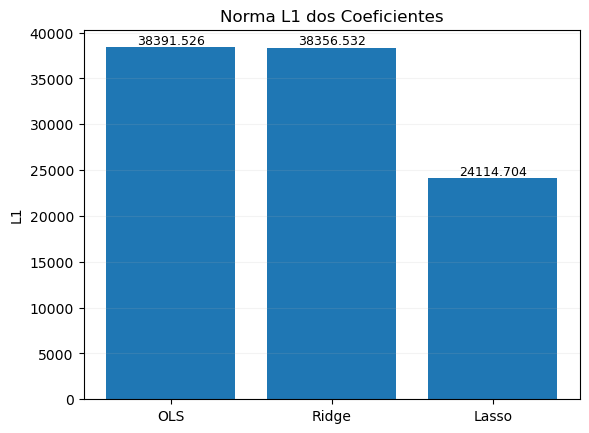

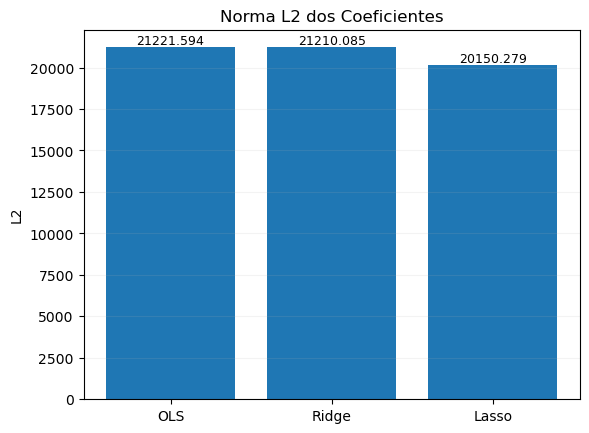

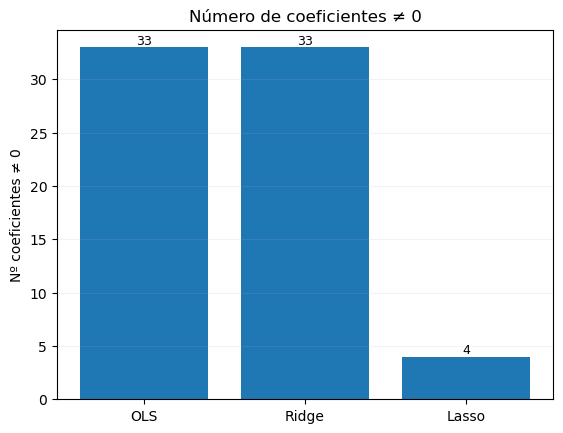

In [35]:
model_names = ["OLS", "Ridge", "Lasso"]

r2_values   = [r2_test,       r2_ridge_test,   r2_lasso_test]
mae_values  = [mae_test,      mae_ridge_test,  mae_lasso_test]
rmse_values = [rmse_test,     rmse_ridge_test, rmse_lasso_test]

def plot_metric_with_zoom(values, title, ylabel, fmt="{:.4f}"):
    plt.figure()
    bars = plt.bar(model_names, values)
    plt.title(title)
    plt.ylabel(ylabel)

    min_v, max_v = min(values), max(values)
    if np.isclose(max_v, min_v):
        margin = abs(max_v) * 0.02 if abs(max_v) > 0 else 0.02
    else:
        margin = (max_v - min_v) * 0.2
    plt.ylim(min_v - margin, max_v + margin)

    for bar, v in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, v, fmt.format(v),
                 ha='center', va='bottom', fontsize=9)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

plot_metric_with_zoom(r2_values, "Comparação de R² entre Modelos", "R²", "{:.4f}")
plot_metric_with_zoom(mae_values, "Comparação de MAE entre Modelos", "MAE", "{:.3f}")
plot_metric_with_zoom(rmse_values, "Comparação de RMSE entre Modelos", "RMSE", "{:.3f}")

coef_ols   = np.array(model.coef_)
coef_ridge = np.array(model_ridge.coef_)
coef_lasso = np.array(model_lasso.coef_)

feature_index = list(X.columns) if hasattr(X, "columns") else list(range(len(coef_ols)))

comparacao_coef = pd.DataFrame({
    "feature": feature_index,
    "OLS": coef_ols,
    "Ridge": coef_ridge,
    "Lasso": coef_lasso
})
display(comparacao_coef.head(20))

plt.figure(figsize=(10, 5))
plt.plot(coef_ols,   marker='o', linestyle='-', label='OLS')
plt.plot(coef_ridge, marker='o', linestyle='-', label='Ridge')
plt.plot(coef_lasso, marker='o', linestyle='-', label='Lasso')
plt.title("Coeficientes por Feature (ordem das features em X.columns)")
plt.xlabel("Índice da feature")
plt.ylabel("Valor do coeficiente")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

norm_l1 = [np.sum(np.abs(coef_ols)), np.sum(np.abs(coef_ridge)), np.sum(np.abs(coef_lasso))]
norm_l2 = [np.sqrt(np.sum(coef_ols**2)), np.sqrt(np.sum(coef_ridge**2)), np.sqrt(np.sum(coef_lasso**2))]

plt.figure()
bars = plt.bar(model_names, norm_l1)
plt.title("Norma L1 dos Coeficientes")
plt.ylabel("L1")
for bar, v in zip(bars, norm_l1):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.15)
plt.show()

plt.figure()
bars = plt.bar(model_names, norm_l2)
plt.title("Norma L2 dos Coeficientes")
plt.ylabel("L2")
for bar, v in zip(bars, norm_l2):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.15)
plt.show()

n_nonzero = [np.sum(coef_ols != 0), np.sum(coef_ridge != 0), np.sum(coef_lasso != 0)]
plt.figure()
bars = plt.bar(model_names, n_nonzero)
plt.title("Número de coeficientes ≠ 0")
plt.ylabel("Nº coeficientes ≠ 0")
for bar, v in zip(bars, n_nonzero):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{int(v)}", ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.15)
plt.show()


A regularização tem como principal objetivo controlar a complexidade do modelo e evitar overfitting, penalizando coeficientes muito grandes.  
Nos resultados obtidos:

- **Ridge Regression (penalização L2):**  
  O modelo Ridge produziu resultados praticamente idênticos ao OLS (R² ≈ 0.912), mostrando que a penalização foi leve, mas suficiente para reduzir ligeiramente a variância dos coeficientes.  

- **Lasso Regression (penalização L1):**  
  Essa simplificação vem com um pequeno custo de desempenho, já que o R² caiu levemente para ≈0.902.

A regularização L2 (Ridge) melhora a estabilidade sem perda de desempenho, enquanto a regularização L1 (Lasso) promove interpretabilidade ao custo de leve redução na precisão. 

# KNN

Agora faremos uma nova regressão baseado em ideias diferentes que é o K-nearest neighbours (KNN). Esse método utiliza os K vizinhos mais próximos de um ponto para determinar seu valor. O número K é um hiperparametro, nós precisamos usar métodos para descobrir seu valor que melhor se encaixe ao nosso problema e nesse caso faremos isso através de cross-validation para evitar overfitting do hiperparametro

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# 1) Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# 2) Search space
param_grid = {
    'knn__n_neighbors': [3,5,7,9,11,13,15],
}

# 3) GridSearch com cross validation
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4) treina só com train
grid.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)

# 5) melhor modelo já vem internamente
best_model = grid.best_estimator_

# 6) avaliação final no TEST
y_pred = best_model.predict(X_test)

print("\n--- Resultados finais no Test ---")
r2 = metrics.r2_score(y_test, y_pred)
print(f"R2 final: {r2:.4f}")


Aqui notamos que o modelo que se saiu melhor foi o com K = 3. Nesse caso testamos apenas para alguns valores de K pois é inviável testar para todos os valores possíveis de K logo testamos os mais razoáveis e comuns. Percebmos que esse modelo obteve um ótimo o que indica que podemos tentar apostar em modelos de árvores que tendem a ser melhores em generalizar mas mantém uma lógica parecida com O KNN já que ambos são modelos não paramétricos, em contraste com os outros modelos de aprendizado supervisionado treinados até aqui que são paramétricos

# GAM 


O **Modelo Aditivo Generalizado (GAM)** é uma extensão da regressão linear que permite capturar relações não lineares. 

O modelo pode ser escrito da seguinte forma:

$$
y=\beta_0 + f_1(x_1) +...+ f_p(x_p) + ϵ
$$

onde $f_i(x_i)$ é função suave que modela o efeito da variável. 

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['airline','source_city','departure_time','stops','arrival_time','destination_city','class','cluster']
for c in cat_cols:
    le = LabelEncoder()
    df_flight[c] = le.fit_transform(df_flight[c])

X = df_flight[['airline','source_city','departure_time','stops','arrival_time',
        'destination_city','class','duration','days_left','cluster']]
y = df_flight['price']

X_train_GAM, X_test_GAM, y_train_GAM, y_test_GAM = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
gam_model = LinearGAM(
    s(0) +        # duration
    s(1) +        # days_left
    f(2) +        # airline
    f(3) +        # source_city
    f(4) +        # departure_time
    f(5) +        # stops
    f(6) +        # arrival_time
    f(7) +        # destination_city
    f(8) +        # class
    f(9)          # cluster
).fit(X_train_GAM, y_train_GAM)

print(gam_model.summary())
y_pred_gam = gam_model.predict(X_test_GAM)


In [ ]:
print("\n--- Resultados da Avaliação do Modelo GAM (Smoothing Splines) ---")

# R-quadrado (R²)
r2_gam = metrics.r2_score(y_test_GAM, y_pred_gam)
print(f"R-quadrado (R²): {r2_gam:.4f}")

In [ ]:
mae_gam = metrics.mean_absolute_error(y_test_GAM, y_pred_gam)
print(f"Erro Absoluto Médio (MAE): ${mae_gam:,.2f}")

In [ ]:
rmse_gam = np.sqrt(metrics.mean_squared_error(y_test_GAM, y_pred_gam))
print(f"Raiz do Erro Quadrático Médio (RMSE): ${rmse_gam:,.2f}")

# XGBOOST


Agora, baseado no bom desempenho do KNN tentaremos ajustar modelos baseados em arvores de decisão, começando pelo XGBOost que é um método como o nome diz de boosting. Métodos de boosting tentam treinam árvores fracas que "consertam" os erros das árvores anteriores, basicamente começando com uma árvore de alto viés e tentando adicionar variância até chegar no ponto ideal do trade-off. O XGBoost especificamente funciona utilizando métodos de gradiente descendente para mimizar o erro de forma eficiente que da o nome ao G do método e o X vem de diversar otimizações em relação a outros métodos que utilizam gradiente para boosting, como regularização, otimização de hardwere e inúmeros hiperparametro que possibilitam fine tunning do modelo.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, make_scorer
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# usar scorer de R²
r2_scorer = make_scorer(r2_score)

results = cross_val_score(xgb_model, X, y, cv=kf, scoring=r2_scorer)

print("======== RESULTADO K-FOLD XGBOOST ========")
print("Scores por Fold (R²):")
for i, r in enumerate(results):
    print(f"Fold {i+1}: {r:.4f}")

print("------------------------------------------")
print(f"Média R²: {results.mean():.4f}")
print(f"Desvio Padrão: {results.std():.4f}")


Reparamos aqui que esse método se saiu muito bem superando ainda por um pequeno valor o KNN.

# RANDOM FOREST

Aqui utilizamoso  random forest, um método também baseado em árvores mas dessa vez em bagging, ele cria uma floresta com quantidade de árvores desejadas utilizando um fator aleátorio para decidir quais predtores pode utilizar em cada nó da árvore, assim ao fazera a média de todas as árvores da floresta a alta variancia de cada uma diminue drasticamente e assim temos um modelo mais robusto.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scorer = make_scorer(r2_score)

results = cross_val_score(rf_model, X, y, cv=kf, scoring=r2_scorer)

print("======== RESULTADO K-FOLD RANDOM FOREST ========")
print("Scores por Fold (R²):")
for i, r in enumerate(results):
    print(f"Fold {i+1}: {r:.4f}")

print("------------------------------------------")
print(f"Média R²: {results.mean():.4f}")
print(f"Desvio Padrão: {results.std():.4f}")


# REDES NEURAIS


Por fim, ajustaremos uma rede neural, um dos tipos de modelo mais famosos atualmente. Nossa rede neural que tenta descrever a relação dos preditores com o preço é de uma arquitetura que contém3 camadas ocultas com 64, 32 e 16 neuronios respectivamente e completamente conectada. Utilizamos a função ReLU que é uma das funções de ativação mais populares, uma taxa de aprendizado de 0.001 contante durante todo o treinament que também é um valor comum, 1000 passagens pelos dados, o solver adam que é um dos mais robustos. ALém disso, estamos usando um fator de regularização alpha de 0.01 que é a constante multiplicativa do termo da soma das normas L2 de cada parametro na função de perda, ou seja, alem de minimizar o erro minmiazmos a soma das normas de cada parametro e também utilizamos o early_stopping que para o treino se a perfromance nao melhorar.

In [ ]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16), # Duas camadas ocultas: a primeira com 64 neurônios, a segunda com 32.
    activation='relu',           # Função de ativação padrão e mais eficiente.
    solver='adam',               # O otimizador mais popular e robusto.
    max_iter=1000,               # Número máximo de épocas (passagens pelos dados).
    alpha=0.01,                  # Parâmetro de regularização para evitar overfitting.
    early_stopping=True,         # Para o treino se a performance não melhorar, evitando overfitting.
    random_state=42
)

# Treinar o modelo com os dados padronizados
mlp_model.fit(X_train_scaled, y_train)

print("Treinamento concluído!")

# --- 4. Avaliação ---
# Fazer previsões com os dados de teste PADRONIZADOS
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Calcular o R²
r2_mlp = metrics.r2_score(y_test, y_pred_mlp)

# Supondo que você salvou o r2 da regressão linear na variável r2_linear
print("\n--- RESULTADO COM MLP (Rede Neural) ---")
print(f"R² do MLP Regressor: {r2_mlp:.4f}")